# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\epsilon\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
(1-\epsilon)\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

In [49]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [50]:
# constants
R_u = 8.314462618       # J/(mol*K)
M_H2 = 2.01588e-3       # kg/mol
R = R_u / M_H2       # J/(kg*K)
T = 300.0           # K
μ = 8.4e-6          # Pa*s = kg/(m*s)
μϵ = 1.0e-9         # Pa*s = kg/(m*s)  for stabilizing purposes, non-physical, should be as small as possible
C_a = 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 7259.0      # kg/m^3
ρ_e = 7164.0        # kg/m^3    initial density solid
E_a = 21179.6       # J/mol
K = 1.0e-9          # m^2, permeability

ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless  used for calculating p_eq, the equilibrium pressure, different for desorption
B_hoffman = 3704.6  # K used for calculating p_eq, the equilibrium pressure

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R_u*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

p_in = 2.0 * p_eqa

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.01215073059348989 s^-1
p_eqa = 192306.14595250844 Pa


In [51]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 3.0;

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))


name = "h. SUPG";

## grid

In [52]:
# generates grid
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [53]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [54]:
# below only to find the dofs of the inlet boundary conditions, 
ch_rho_left = ConstraintHandler(dh)

dummy_rho = Dirichlet(
    :rho,
    left,
    (x, t) -> 0.0,
)

add!(ch_rho_left, dummy_rho)
close!(ch_rho_left)

inlet_rho_dofs = copy(ch_rho_left.prescribed_dofs)

ch_v_left = ConstraintHandler(dh)

dummy_v = Dirichlet(
    :v,
    left,
    (x, t) -> 0.0,
)

add!(ch_v_left, dummy_v)
close!(ch_v_left)

inlet_v_dofs = copy(ch_v_left.prescribed_dofs);

In [55]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)
add!(ch_lin, right_v)

close!(ch_lin)
update!(ch_lin, 0.0)

# for the non-linear constraint I only need to constrain the inlet density to fullfill a total pressure bc
ch_ptot = ConstraintHandler(dh)    
inlet_p_tot = Dirichlet(
    :rho,
    left,
    (x, t) -> p_in
)
add!(ch_ptot, inlet_p_tot)
close!(ch_ptot)
update!(ch_ptot, 0.0)


In [56]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [57]:
struct RHSparams
    M::SparseMatrixCSC                  # Mass matrix updated each timestep
    A::SparseMatrixCSC                  # Au in the matrix system
    N::Vector{Float64}                  # Non-linear part directly assembled into matrix
    Me::Matrix                          # Element matrix for assembling mass matrix
    Ae::Matrix                          # Element matrix for assembling 
    A_a::Float64                        # Mass absorption coefficient, A_a = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
    R::Float64                          # Per kg 
    T::Float64                          # Temperature
    p_eqa::Float64                      # Equilibrium pressure
    rho_sat::Float64                    # Saturation density
    ϵ::Float64                          # Porosity
    μ::Float64                          # Viscosity
    μϵ::Float64                         # Stabilizing viscosity
    K::Float64                          # Permeability
    assemble_operators!::Function       # Complete assembly of the mass matrix M, A, and the non-linear part N
    dh::DofHandler              
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    cellvalues_v::CellValues
    inlet_v_dofs::Vector{Int}
    inlet_rho_dofs::Vector{Int}
    ch_lin::ConstraintHandler           # constraint handler for the linear constraints, (Dirichlet BCs on velocity at borders battery)
    ch_ptot::ConstraintHandler          # constraint handler for the non-linear constraints, (total pressure BCs)
end

In [ ]:
function assemble_operators!(
    u::Vector{Float64},
    params::RHSparams
)

    # create these params in params, also need Ae, Me. 
    # N I assemble without an assembler or Ne (directly)
    fill!(params.M, 0.0)
    fill!(params.A, 0.0)
    fill!(params.N, 0.0)
    
    assembler_M = start_assemble(params.M)
    assembler_A = start_assemble(params.A)

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    for cell in CellIterator(params.dh)

        fill!(params.Me, 0.0)
        fill!(params.Ae, 0.0)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        # now for tau
        v_K  = maximum(abs, v_local)
        ρg_K = sum(rhog_local) / length(rhog_local)

        Pe_v = v_K * params.h * ρg_K / (2 * params.μ)
        Pe_ρ = v_K * params.h / (2 * params.μϵ)

        if Pe_v < 1e-6
            # diffusion-dominated limit
            τ_v = ρg_K * params.h^2 / (12 * params.μ)
        else
            τ_v = params.h / (2 * a_v) * (coth(Pe_v) - 1 / Pe_v)
        end

        if Pe_ρ < 1e-6
            # diffusion-dominated limit
            τ_ρ = params.ϵ * params.h^2 / (12 * params.μϵ)
        else
            τ_ρ = params.ϵ * params.h / (2 * v_K) * (coth(Pe_ρ) - 1 / Pe_ρ)
        end        

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, drhog/dx, rhos, v, dv/dx, and d(rhog v)/dx (by product rule) at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            drhog_q = sum(
                rhog_local[j] *
                shape_gradient(params.cellvalues_rhog,q,j)[1]
                for j in 1:length(rhog_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          
            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            drhogv_q = v_q * drhog_q + rhog_q * dv_q

            # dot m =       A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)

            # v terms
            for k in 1:length(v_local)
                ψk  = shape_value(params.cellvalues_v, q, k)
                dψk = shape_gradient(params.cellvalues_v, q, k)     
                
                for i in 1:length(v_local)

                    ψi = shape_value(params.cellvalues_v, q, i)
                    dψi = shape_gradient(params.cellvalues_v, q, i)

                    # S term. Viscous dissipation
                    params.Ae[v_dofs[k], v_dofs[i]] += -params.μ / params.K * ψk * ψi * dx

                    # D diffusion
                    params.Ae[v_dofs[k], v_dofs[i]] += -params.μ * dot(dψk, dψi) * dx

                    # Mass term
                    params.Me[v_dofs[k], v_dofs[i]] += rhog_q*ψk*ψi*dx

                end

                for i in 1:length(rhog_local)

                    dψi = shape_gradient(params.cellvalues_rhog, q, i)

                    # pressure term
                    params.Ae[v_dofs[k], rhog_dofs[i]] += -params.R*params.T*ψk*dψi[1]*dx

                end

                # Convection term of v
                params.N[cell_dofs[v_dofs[k]]] += ψk * rhog_q * v_q *dv_q * dx            
            end            

            # rhog terms
            for k in 1:length(rhog_local)
                
                ψk  = shape_value(params.cellvalues_rhog,q,k)
                dψk = shape_gradient(params.cellvalues_rhog,q,k)
                
                for i in 1:length(rhog_local)
                    
                    ψi = shape_value(params.cellvalues_rhog, q, i)
                    dψi = shape_gradient(params.cellvalues_rhog, q, i)

                    # D for stability; maybe unnecessary by SUPG implementation?
                    params.Ae[rhog_dofs[k], rhog_dofs[i]] += -params.μϵ * dot(dψk, dψi) * dx

                    # Mass term
                    params.Me[rhog_dofs[k], rhog_dofs[i]] += params.ϵ *ψk*ψi*dx
                
                end

                # mass transfer
                params.N[cell_dofs[rhog_dofs[k]]] -= ψk*mdot_q*dx

                # convection
                params.N[cell_dofs[rhog_dofs[k]]] += dψk[1] * v_q * rhog_q * dx
            end


            # rhos terms
            for k in 1:length(rhos_local)

                ψk = shape_value(params.cellvalues_rhos,q,k)

                for i in 1:length(rhos_local)
                    
                    ψi = shape_value(params.cellvalues_rhos, q, i)

                    # Mass term
                    params.Me[rhos_dofs[k], rhos_dofs[i]] += (1-params.ϵ)*ψk*ψi*dx
                end

                # Mass transfer
                params.N[cell_dofs[rhos_dofs[k]]] += ψk*mdot_q*dx
            end
        end
        
        assemble!(assembler_M, cell_dofs, params.Me)
        assemble!(assembler_A, cell_dofs, params.Ae)
    end
end

assemble_operators! (generic function with 1 method)

In [59]:
# Measures for matrix and vector allocation
first_cell = first(CellIterator(dh))        # temporary variable to find the number of dofs per cell
ndofs_cell = length(celldofs(first_cell))   # amount of dofs per cell, used for allocating element matrices
ndofs_total = ndofs(dh)                     # total amount of dofs, used for allocating global matrices and vectors

# State vectors
u      = zeros(ndofs_total)
du     = zeros(ndofs_total)

# Initialization of matrices
M     = allocate_matrix(dh)
A     = allocate_matrix(dh)
N     = zeros(ndofs_total)          # a vector

# Element matrices
Me = zeros(ndofs_cell, ndofs_cell)
Ae = zeros(ndofs_cell, ndofs_cell)

# Initial condition
apply_analytical!(u, dh, :rho, x -> p_eqa/(R*T))
apply_analytical!(u, dh, :rho_s, x -> ρ_e)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

# Initial non-linear BC application
update!(ch_ptot, 0.0)
for k in eachindex(ch_ptot.prescribed_dofs)

    rho_dof = ch_ptot.prescribed_dofs[k]
    v_dof   = inlet_v_dofs[k]

    v = u[v_dof]
    p_tot_bc = ch_ptot.inhomogeneities[k]

    u[rho_dof] =
        p_tot_bc /
        (
            R * T +
            0.5 * v^2
        )
end


In [60]:
params = RHSparams(
    M,
    A,
    N,
    Me,
    Ae,
    A_a, 
    R, 
    T, 
    p_eqa, 
    ρ_sat, 
    ϵ,   # Porosity
    μ,   # Viscosity
    μϵ,   # Stabilizing viscosity
    K,   # Permeability
    assemble_operators!,
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    inlet_v_dofs,
    inlet_rho_dofs,
    ch_lin,
    ch_ptot
)

# struct RHSparams
#     M::SparseMatrixCSC                  # Mass matrix updated each timestep
#     A::SparseMatrixCSC                  # Au in the matrix system
#     N::Vector{Float64}                  # Non-linear part directly assembled into matrix
#     Me::Matrix                          # Element matrix for assembling mass matrix
#     Ae::Matrix                          # Element matrix for assembling 
#     A_a::Float64                        # Mass absorption coefficient, A_a = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
#     R::Float64                          # Per kg 
#     T::Float64                          # Temperature
#     p_eqa::Float64                      # Equilibrium pressure
#     rho_sat::Float64                    # Saturation density
#     assemble_operators!::Function       # Complete assembly of the mass matrix M, A, and the non-linear part N
#     dh::DofHandler              
#     cellvalues_rhog::CellValues
#     cellvalues_rhos::CellValues
#     cellvalues_v::CellValues
#     inlet_v_dofs::Vector{Int}
#     inlet_rho_dofs::Vector{Int}
# end

RHSparams(sparse([1, 2, 3, 4, 5, 6, 1, 2, 3, 4  …  300, 301, 302, 303, 298, 299, 300, 301, 302, 303], [1, 1, 1, 1, 1, 1, 2, 2, 2, 2  …  302, 302, 302, 302, 303, 303, 303, 303, 303, 303], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 303, 303), sparse([1, 2, 3, 4, 5, 6, 1, 2, 3, 4  …  300, 301, 302, 303, 298, 299, 300, 301, 302, 303], [1, 1, 1, 1, 1, 1, 2, 2, 2, 2  …  302, 302, 302, 302, 303, 303, 303, 303, 303, 303], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 303, 303), [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 0.01215073059348989, 4124.482914657619, 300.0, 192306.14595250844, 7259.0, 0.4, 8.4e-6, 1.0e-9, 1.0e-9, Main.assemble_operators!, DofHa

In [61]:
function res!(res, du, u, params, t)

    assemble_operators!(u, params)

    # R = M(u)du - A(u)u - N(u)
    mul!(res, params.M, du)
    mul!(res, params.A, u, -1.0, 1.0)
    res .-= params.N
    
    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end

    # non-linear constraints
    update!(params.ch_ptot, t)
    for k in 1:length(params.ch_ptot.prescribed_dofs)

        rho_dof = params.ch_ptot.prescribed_dofs[k]
        v_dof   = params.inlet_v_dofs[k]
        ρ = u[rho_dof]
        v = u[v_dof]
        value = params.ch_ptot.inhomogeneities[k]

        p_tot = 0.5 * ρ * v^2 + params.R * params.T * ρ

        res[rho_dof] = p_tot - value
    end
end

# \rho_g op de inlet
# \rho_g = rho_t - (1/2) m v^2

res! (generic function with 1 method)

In [62]:
params.assemble_operators!(u, params)

# du = params.M \ (params.A * u + params.N)
du .= params.M \ (params.A * u .+ params.N)

for k in 1:length(params.ch_lin.prescribed_dofs)

    dof = params.ch_lin.prescribed_dofs[k]
    du[dof] = 0
    
end
for k in 1:length(params.ch_ptot.prescribed_dofs)

    dof = params.ch_lin.prescribed_dofs[k]
    du[dof] = 0
end

In [63]:
test_res = zeros(ndofs_total)
res!(test_res, du, u, params, 0.0)

In [64]:
using DifferentialEquations

In [65]:
differential_vars = trues(length(u))

# the bc are not of the form du/dt = f(u), but rather f(u) = 0. So we need to set the differential_vars of the prescribed dofs to false
for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end
for dof in ch_ptot.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, 0.000101)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(
    prob, 
    # initializealg=DiffEqBase.BrownFullBasicInit(),
    saveat=0.000001, 
    reltol=1e-8, 
    abstol=1e-8
)

retcode: Success
Interpolation: 1st order linear
t: 102-element Vector{Float64}:
 0.0
 1.0e-6
 2.0e-6
 3.0e-6
 4.0e-6
 5.0e-6
 6.0e-6
 7.0e-6
 8.0e-6
 9.0e-6
 1.0e-5
 1.1e-5
 1.2e-5
 ⋮
 9.0e-5
 9.1e-5
 9.2e-5
 9.3e-5
 9.4e-5
 9.5e-5
 9.6e-5
 9.7e-5
 9.8e-5
 9.9e-5
 0.0001
 0.000101
u: 102-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.31083677628063283, 0.15541838814031642, 7164.0, 7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0  …  7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.15541838814031642, 7164.0]
 [79.00085861211271, 57.160274749699354, 0.3100548220016777, 0.15799840126641224, 7164.000001419466, 7164.00000005028, -14.767793433590045, 0.15563488643105056, 7163.999999990278, 3.9874889060177963  …  7164.0, -3.1360873449243463e-16, 0.15541838814031642, 7164.0, 8.960522141763715e-17, 0.15541838814031642, 7164.0, 0.0, 0.15541838814031642, 7164.0]
 [151.9124631842042, 109.18029835916887, 0.3079648897390406, 0.16541165781687392, 7164.0000028211125, 71

In [21]:
sol.alg

Sundials.IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

## Plotting/animating

In [22]:
using Plots

In [44]:
U = Array(sol);

In [45]:
# double gif plot
foldername = name

U = Array(sol)

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

# ptot = 1/2 rho v^2 + R T rho
ptot = 0.5 * sol_ρ .* sol_v.^2 .+ R * T * sol_ρ

ptotmin = minimum(ptot)
ptotmax = maximum(ptot)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:100

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density gas",
        color=:blue,
        xlabel="x",
        ylabel="density [kg/m3]",
        ylims=(0, ρmax),
        title="t = $(round(discrete_t[k]*1000, digits=5))ms",
        legend=:topright
    )

    p2  = plot(
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
        ylims=(rhosmin, rhosmax),
        xlabel="x",
        ylabel="density [kg/m3]",
        legend=:topright
    )

    p3 = plot(
        discrete_x,
        ptot[:, k],
        label="total pressure",
        color=:orange,
        ylims=(ptotmin, ptotmax),
        xlabel="x",
        ylabel="total pressure [Pa]",
        legend=:topright
    )

    p4 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity [m/s]",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, p3, p4, layout=(2,2), size=(800,600))
end

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_jdOo3P", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000091.png", "000092.png", "000093.png", "000094.png", "000095.png", "000096.png", "000097.png", "000098.png", "000099.png", "000100.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\g. realistic values\NO_SUPG.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\NO_SUPG.gif")
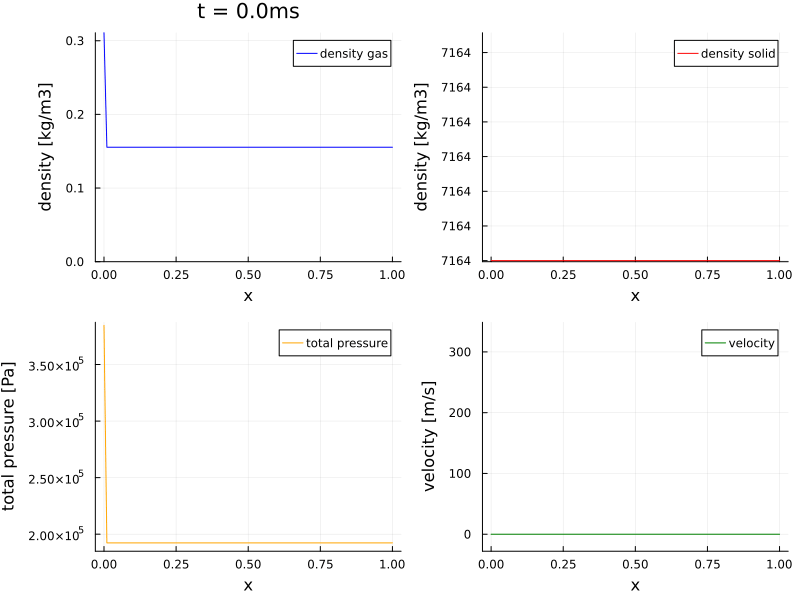

In [46]:
gif(anim, joinpath(foldername, "NO_SUPG.gif"), fps=10)

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\g. realistic values\real_values_opening_vat.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\real_values_opening_vat.gif")
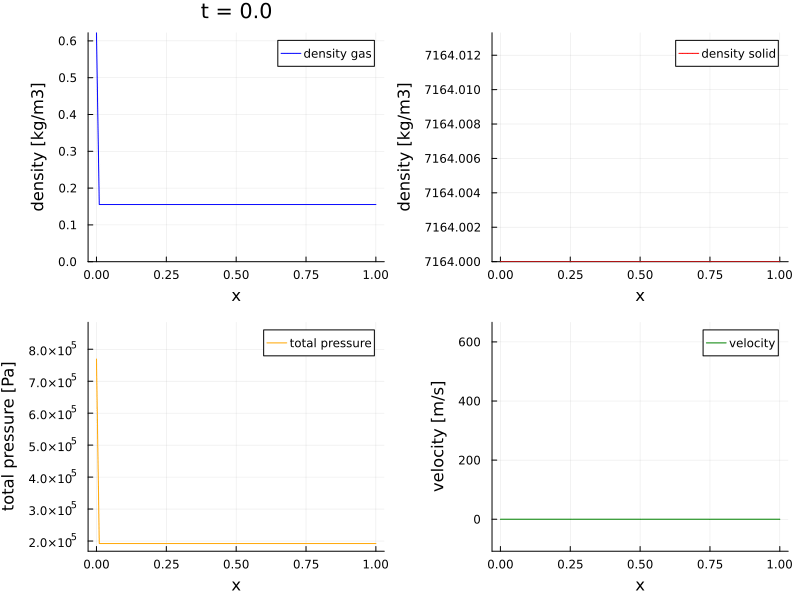

In [ ]:
gif(anim, joinpath(foldername, "real_values_long_term.gif"), fps=10)

In [89]:
p_eqa / (R*T)

0.15541838814031642

In [90]:
R

4124.482914657619

In [88]:
T

300.0

In [91]:
A_a

0.01215073059348989

In [ ]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

In [ ]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [ ]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

In [ ]:
# report_figures_folder = "..\\report\\figures\\"
# folder = mkpath(report_figures_folder)
# name = "A.png"
# savefig(joinpath(folder, name))